In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])

In [2]:
def load_xvg(filename, Dt):
    time = []
    prop = []
    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('#') or line.startswith('@'):
                continue  # Skip comments and metadata
            parts = line.split()
            if len(parts) >= 2:
                time.append(float(parts[0]))
                prop.append(float(parts[1]))

    time = np.array(time)
    prop = np.array(prop)+0.01*1000

    if len(time) == 0:
        raise ValueError(f"No data found in {filename}. Please check the file format.")
    
    bins = np.ceil(time[-1]/1000 / Dt).astype(int)  # Number of bins for averaging
    time_chunks = np.array_split(time, bins)
    prop_chunks = np.array_split(prop, bins)

    mean_time = [np.mean(chunk) for chunk in time_chunks]
    mean_prop = [np.mean(chunk) for chunk in prop_chunks]

    return time, prop, mean_time, mean_prop

Mean Density: 1.2550 g/cm^3
Mean Density of the last 30% of data: 1.2554 g/cm^3


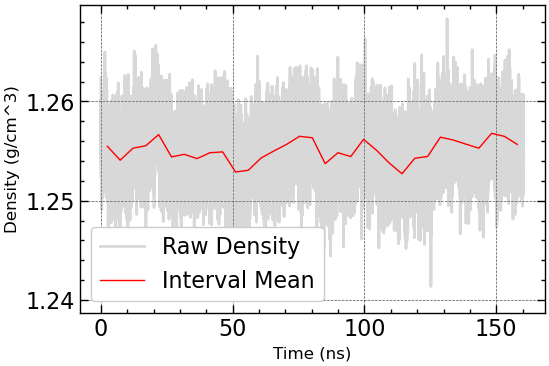

In [4]:
filename = 'density.xvg'  # Replace with your .xvg file path
Dt = 5  # Interval in ns for averaging

time, rho, mean_time, mean_rho = load_xvg(filename, Dt=Dt)
mean_time = np.array(mean_time)
mean_rho = np.array(mean_rho)

# 3. Plot the results
plt.figure(figsize=(6, 4))

# Plot raw data in the background (semi-transparent)
plt.plot(time/1000, rho/1000, color='gray', alpha=0.3, label='Raw Density')

# Plot the 100-interval mean on top
plt.plot(np.array(mean_time)/1000, np.array(mean_rho/1000), color='red', linewidth=1, label=f'Interval Mean')

# y range
# plt.ylim(1.2, 1.3)  # Adjust based on your data range
# plt.xlim(0, 100)  # Adjust based on your data range

# Formatting
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Density (g/cm^3)', fontsize=12)
# plt.title('System Density vs. Time', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
# y range

# compute the mean
prop_mean = np.mean(rho/1000)
print(f"Mean Density: {prop_mean:.4f} g/cm^3")
# mean of the last 30% of data
print(f"Mean Density of the last 30% of data: {np.mean(rho[int(len(rho)*0.7):]/1000):.4f} g/cm^3")

# last simulation 1.2545
